# ECOD (Empirical Cumulative Distribution-based Outlier Detection) for Fraud Anomaly Detection

This script uses the `cms_general_payments_anomaly_ready.csv` or the `unified_dataset.csv` and applies ECOD for fraud anomaly detection. ECOD is a parameter-free, deterministic unsupervised anomaly detection algorithm that identifies outliers based on empirical cumulative distribution functions. Because it has no trainable hyperparameters, results are fully reproducible across runs.

The notebook includes:
- Data preprocessing with standard scaling
- ECOD model training (no hyperparameter tuning required — deterministic and fully reproducible)
- Anomaly score analysis
- **Per-feature contribution analysis** (explainability unique to ECOD)
- Individual anomaly explanations
- Visualization of detected anomalies
- **Percentile binning** to Low / Medium / High / Critical severity labels
- **Confusion matrix based on top 5% anomalous threshold**
- **Aggregate anomaly scores to Provider-Year** (Step 2.3)
- **Model export for ensemble integration**

The test data is 40% of the original data. This notebook takes less than 1 minute to run!

## Install and Import Dependencies


In [1]:
!pip install pyod --quiet

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
from pyod.models.ecod import ECOD
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix,
    average_precision_score, precision_recall_curve,
    roc_auc_score
)
from sklearn.decomposition import PCA
from sklearn.feature_selection import SelectKBest, mutual_info_classif
import joblib
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
print('Imports OK')

Imports OK


## Configuration

This section defines the dataset path, core modeling columns, score bins, and output artifacts used throughout the notebook.


In [3]:
# Dataset configurations
DATASET_CONFIGS = {
    "cms_general_payments": {
        "data_path": "/dsa/groups/casestudycf25/team02/silver/cms_general_payments_anomaly_ready.csv",
        "id_cols": ["covered_recipient_npi", "record_id", "program_year"],
        "target_col": "target",
        "provider_col": "covered_recipient_npi",
        "year_col": "program_year"
    },
    "legacy_unified_dataset": {
        "data_path": "/dsa/groups/casestudycf25/team02/gold/unified_dataset.csv",
        "id_cols": ["npi"],
        "target_col": "target",
        "provider_col": "npi",
        "year_col": "program_year"
    }
}

# Choose one active dataset
ACTIVE_DATASET = "cms_general_payments"
CFG = DATASET_CONFIGS[ACTIVE_DATASET]

# Dataset and core columns
DATA_PATH = CFG["data_path"]
ID_COLS = CFG["id_cols"]
TARGET_COL = CFG["target_col"]
PROVIDER_COL = CFG["provider_col"]
YEAR_COL = CFG["year_col"]
NULL_FILL = -1

# Train-test split
TEST_SIZE = 0.40
RANDOM_SEED = 42

# ECOD threshold setting
CONTAMINATION = 0.05

# Anomaly score bins applied to full-dataset scores
# Low  = [0, P50)
# Medium   = [P50, P90)
# High = [P90, P95)
# Critical = [P95, 100]
BIN_PERCENTILES = [50, 90, 95]
BIN_LABELS = ['Low', 'Medium', 'High', 'Critical']
REQUIRED_COLS = ID_COLS + [TARGET_COL, PROVIDER_COL, YEAR_COL]

#  Output filenames 
OUT_MODEL = 'ecod_model.pkl'
OUT_SCALER = 'ecod_scaler.pkl'
OUT_REFS = 'ecod_reference_scores.pkl'
OUT_CSV = 'ecod_predictions.csv'

print(f'Configuration loaded for dataset: {ACTIVE_DATASET}')
print(f'Data path: {DATA_PATH}')

Configuration loaded for dataset: cms_general_payments
Data path: /dsa/groups/casestudycf25/team02/silver/cms_general_payments_anomaly_ready.csv


## Load and Prepare Data


In [4]:
# Load the selected dataset and validate the required schema
df = pd.read_csv(DATA_PATH)

missing_cols = [c for c in REQUIRED_COLS if c not in df.columns]
if missing_cols:
    raise ValueError(
        f"Dataset '{ACTIVE_DATASET}' is missing required columns: {missing_cols}"
    )

print(f"Active dataset: {ACTIVE_DATASET}")
print(f"Dataset shape: {df.shape}")
print(f"Target distribution:\n{df[TARGET_COL].value_counts()}")
df.head()

Active dataset: cms_general_payments
Dataset shape: (932908, 53)
Target distribution:
target
0    932441
1       467
Name: count, dtype: int64


,record_id,covered_recipient_npi,target,total_amount_of_payment_us_dollars,avg_amount_per_payment,log_total_amount,number_of_payments_included_in_total_amount,payment_to_publication_lag_days,payment_month,payment_quarter,...,dme_hospital_beds,dme_replacement_batteries,dme_tapes_and_medical_supplies,nature_short_descr_enc,form_of_payment_or_transfer_of_value_enc,covered_recipient_primary_type_1_enc,recipient_state_enc,specialty_type_enc,specialty_lvl1_enc,specialty_enc
0,1006679101,1750964185,0,10.58,10.58,2.449279,1.0,640.0,9.0,3.0,...,0.0,0.0,0.0,7.0,2.0,5.0,2.0,5.0,1.0,61.0
1,1006696505,1417944091,0,8.23,8.23,2.222459,1.0,741.0,6.0,2.0,...,0.0,0.0,0.0,7.0,2.0,5.0,2.0,5.0,1.0,61.0
2,1006744861,1699208850,0,10.33,10.33,2.427454,1.0,880.0,2.0,1.0,...,0.0,0.0,0.0,7.0,2.0,4.0,8.0,4.0,7.0,72.0
3,1006725903,1124052717,0,6.57,6.57,2.024193,1.0,733.0,6.0,2.0,...,0.0,0.0,0.0,10.0,0.0,4.0,2.0,4.0,7.0,72.0
4,1006725915,1124052717,0,90.79,90.79,4.519503,1.0,714.0,7.0,3.0,...,0.0,0.0,0.0,7.0,2.0,4.0,2.0,4.0,7.0,72.0


In [5]:
missing = df.isnull().sum()
print(f'Columns with nulls: {(missing > 0).sum()}')
if (missing > 0).any():
    print(missing[missing > 0].sort_values(ascending=False).head(10))

df = df.fillna(NULL_FILL)
print(f'Nulls filled with {NULL_FILL}.')


Columns with nulls: 0
Nulls filled with -1.


In [6]:
# Candidate feature set before dropping columns from modeling
drop_cols = ID_COLS + [TARGET_COL]
candidate_feature_cols = [c for c in df.columns if c not in drop_cols]

X_candidates = df[candidate_feature_cols].apply(pd.to_numeric, errors='coerce').fillna(NULL_FILL)
y = df[TARGET_COL].astype(int).values

TOP_K_FEATURES = min(25, X_candidates.shape[1])

selector = SelectKBest(score_func=mutual_info_classif, k=TOP_K_FEATURES)
selector.fit(X_candidates, y)

feature_rankings_df = (
    pd.DataFrame({
        "feature": X_candidates.columns,
        "mutual_info_score": selector.scores_,
        "selected": selector.get_support()
    })
    .sort_values(["selected", "mutual_info_score"], ascending=[False, False])
    .reset_index(drop=True)
)

selected_feature_cols = feature_rankings_df.loc[
    feature_rankings_df["selected"], "feature"
].tolist()

feature_cols = selected_feature_cols
X = X_candidates[feature_cols].values

print(f"Candidate features: {len(candidate_feature_cols)}")
print(f"Selected features:  {len(feature_cols)}")
print("\nTop selected features by mutual information:")
display(feature_rankings_df.head(20))


Candidate features: 49
Selected features:  25

Top selected features by mutual information:


,feature,mutual_info_score,selected
0,is_third_party_payment,0.205072,True
1,number_of_payments_included_in_total_amount,0.204575,True
2,form_of_payment_or_transfer_of_value_enc,0.178621,True
3,nature_short_descr_enc,0.156879,True
4,covered_device,0.148985,True
5,specialty_type_enc,0.109033,True
6,covered_recipient_primary_type_1_enc,0.105321,True
7,specialty_lvl1_enc,0.091108,True
8,payment_quarter,0.047199,True
9,is_q4_payment,0.041777,True


## Train-Test Split and Scaling


In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_SEED,
    stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f'Train: {X_train_scaled.shape}  |  Test: {X_test_scaled.shape}')
print(f'Train fraud count: {y_train.sum()}  |  Test fraud count: {y_test.sum()}')

Train: (559744, 25)  |  Test: (373164, 25)
Train fraud count: 280  |  Test fraud count: 187


## AUPRC-Based Model Validation

ECOD does not require the same hyperparameter search used by Isolation Forest and INNE; this section validates a single deterministic configuration on the held-out test split using AUPRC.


In [8]:
validation_model = ECOD(contamination=CONTAMINATION)
validation_model.fit(X_train_scaled)

validation_scores = validation_model.decision_function(X_test_scaled)
validation_predictions = validation_model.predict(X_test_scaled)

validation_auprc = average_precision_score(y_test, validation_scores)
validation_roc_auc = roc_auc_score(y_test, validation_scores)

print('ECOD validation complete (deterministic; results are fully reproducible).')
print(f'Contamination setting: {CONTAMINATION}')
print(f'Internal threshold: {validation_model.threshold_:.4f}')
print(f'Validation AUPRC: {validation_auprc:.4f}')
print(f'Validation ROC-AUC: {validation_roc_auc:.4f}')


ECOD validation complete (deterministic; results are fully reproducible).
Contamination setting: 0.05
Internal threshold: 27.3801
Validation AUPRC: 0.0007
Validation ROC-AUC: 0.6308


In [9]:
##############################################
# Run History
##############################################

run_history = pd.DataFrame([
    {
        'contamination': CONTAMINATION,
        'threshold': float(validation_model.threshold_),
        'auprc': float(validation_auprc),
        'roc_auc': float(validation_roc_auc),
    }
])

print('Run history summary:')
print(run_history.to_string(index=False))


Run history summary:
 contamination  threshold    auprc  roc_auc
          0.05  27.380137 0.000715 0.630784


## Train Final Model

Using the same deterministic ECOD configuration, this cell fits the final model used for scoring, visualization, and artifact generation.


In [10]:
ecod = ECOD(contamination=CONTAMINATION)
ecod.fit(X_train_scaled)

train_scores = ecod.decision_function(X_train_scaled)
test_scores = ecod.decision_function(X_test_scaled)
test_predictions = ecod.predict(X_test_scaled)

X_all_scaled = scaler.transform(X)
all_scores = ecod.decision_function(X_all_scaled)

auprc_val = average_precision_score(y_test, test_scores)
roc_auc = roc_auc_score(y_test, test_scores)

print(f'Final ECOD threshold: {ecod.threshold_:.4f}')
print(f'Test AUPRC: {auprc_val:.4f}')
print(f'Test ROC-AUC: {roc_auc:.4f}')


Final ECOD threshold: 27.3801
Test AUPRC: 0.0007
Test ROC-AUC: 0.6308


## Anomaly Score Distribution Analysis

The score bins below are derived from the full dataset so the same thresholds can be reused consistently in downstream scoring.


## Percentile-Based Anomaly Binning

The score bins below are derived from the full dataset so the same thresholds can be reused consistently in downstream scoring.


In [11]:
cutoffs = np.percentile(all_scores, BIN_PERCENTILES)
print(f'Bin cutoffs (percentiles {BIN_PERCENTILES}): {cutoffs.round(4)}')

def assign_bins(scores, cutoffs, labels):
    """Assign scores to named bins using fixed percentile cutoffs."""
    bins = np.full(len(scores), labels[0], dtype=object)
    for cutoff, label in zip(cutoffs, labels[1:]):
        bins[scores >= cutoff] = label
    return bins

all_bins   = assign_bins(all_scores,   cutoffs, BIN_LABELS)
train_bins = assign_bins(train_scores, cutoffs, BIN_LABELS)
test_bins  = assign_bins(test_scores,  cutoffs, BIN_LABELS)

bin_counts = pd.Series(all_bins).value_counts().reindex(BIN_LABELS)
print('\nBin distribution (full dataset):')
print(bin_counts.to_frame('count').assign(pct=lambda d: (d['count']/len(all_bins)*100).round(1)))

Bin cutoffs (percentiles [50, 90, 95]): [16.8385 24.7138 27.3587]

Bin distribution (full dataset):
           count   pct
Low       466454  50.0
Medium    373161  40.0
High       46647   5.0
Critical   46646   5.0


## Visual Verification Dashboard


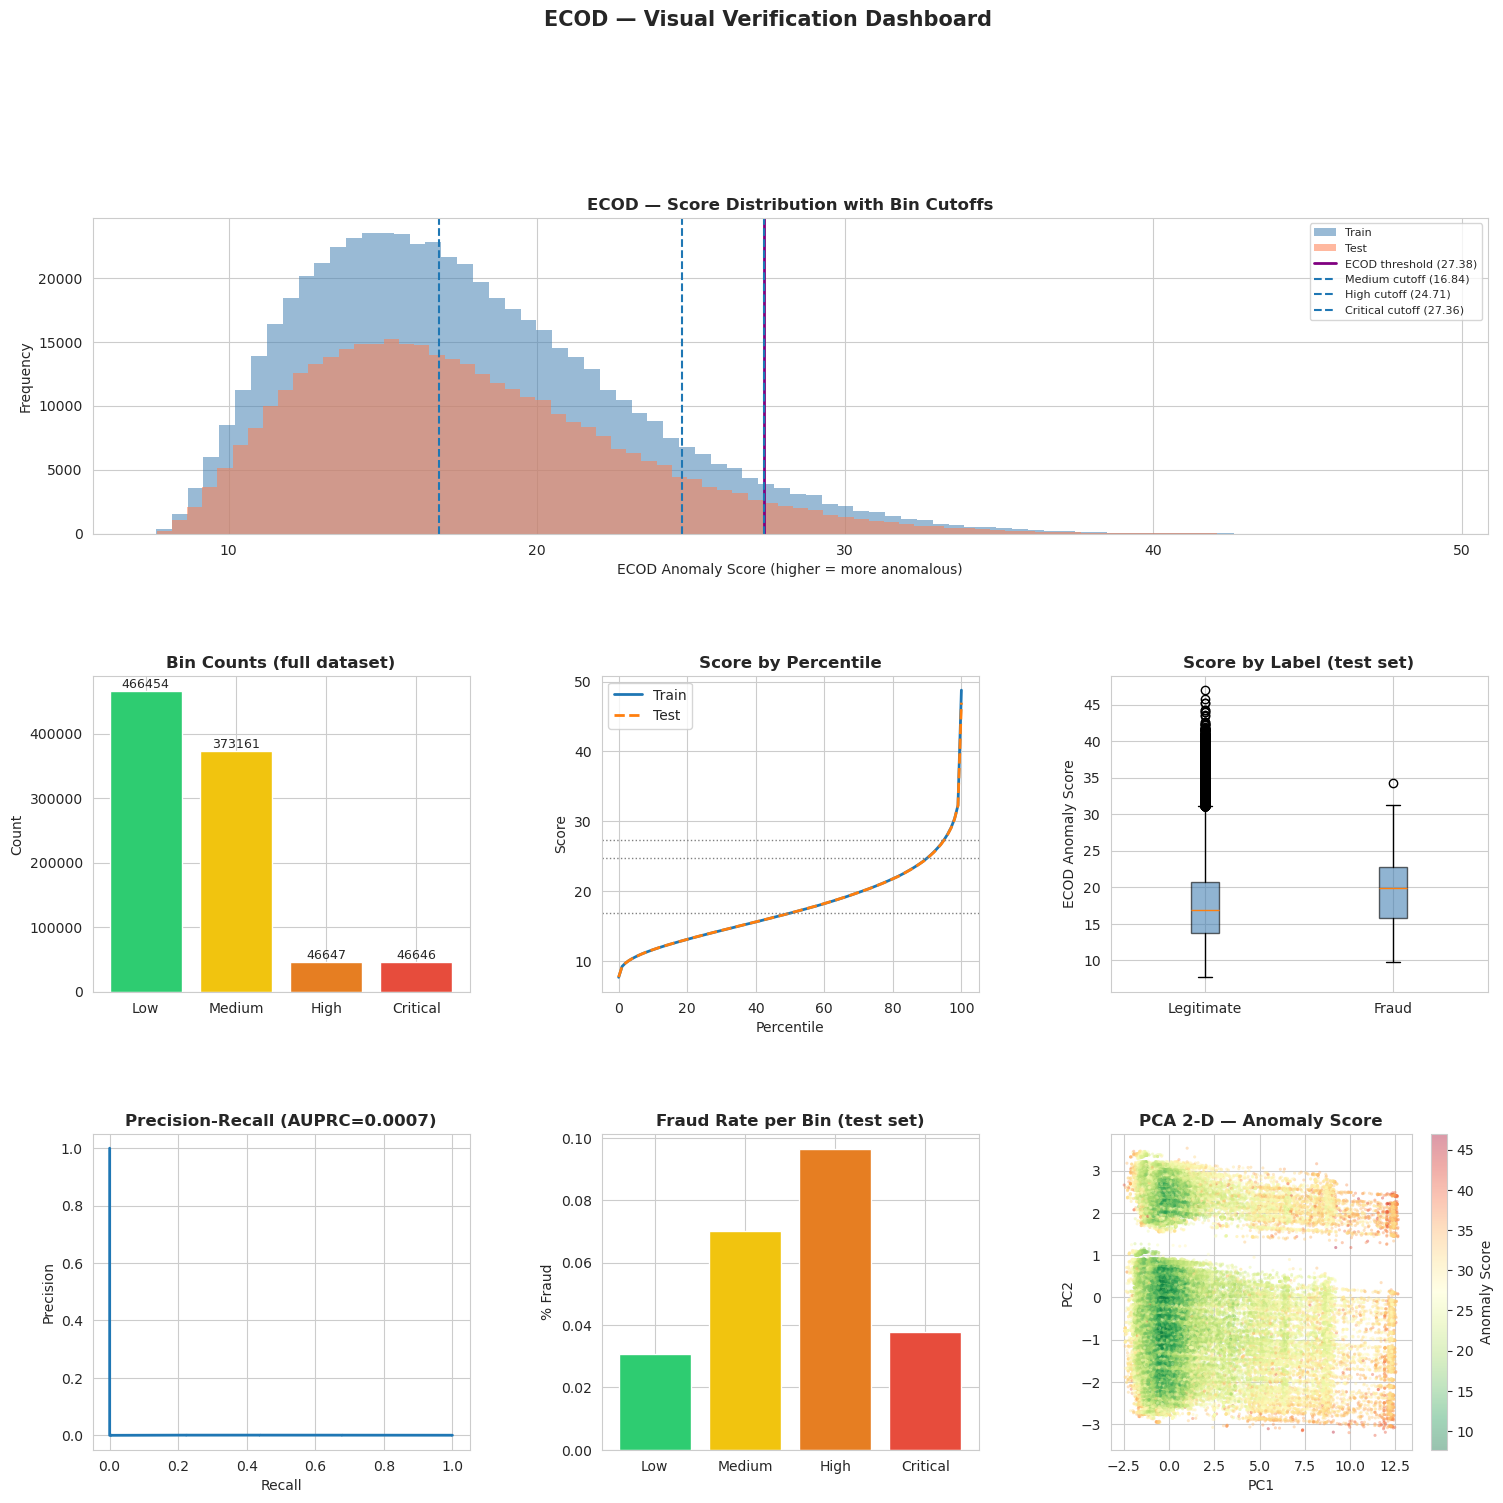


Summary: AUPRC=0.0007 | ROC-AUC=0.6308 | Critical count=46646 (5.0%)


In [12]:
fig = plt.figure(figsize=(18, 16))
gs  = gridspec.GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.35)
colors = ['#2ecc71', '#f1c40f', '#e67e22', '#e74c3c']

#  Panel A: Score distribution 
ax_a = fig.add_subplot(gs[0, :])
ax_a.hist(train_scores, bins=80, alpha=0.55, label='Train', color='steelblue', edgecolor='none')
ax_a.hist(test_scores,  bins=80, alpha=0.55, label='Test',  color='coral',     edgecolor='none')
ax_a.axvline(ecod.threshold_, color='purple', linestyle='-',  linewidth=2, label=f'ECOD threshold ({ecod.threshold_:.2f})')
for c, lbl in zip(cutoffs, BIN_LABELS[1:]):
    ax_a.axvline(c, linestyle='--', linewidth=1.5, label=f'{lbl} cutoff ({c:.2f})')
ax_a.set_xlabel('ECOD Anomaly Score (higher = more anomalous)')
ax_a.set_ylabel('Frequency')
ax_a.set_title('ECOD — Score Distribution with Bin Cutoffs', fontweight='bold')
ax_a.legend(fontsize=8)

#  Panel B: Bin bar chart 
ax_b = fig.add_subplot(gs[1, 0])
ax_b.bar(BIN_LABELS, bin_counts.values, color=colors, edgecolor='white')
ax_b.set_title('Bin Counts (full dataset)', fontweight='bold')
ax_b.set_ylabel('Count')
for i, v in enumerate(bin_counts.values):
    ax_b.text(i, v + max(bin_counts)*0.01, str(v), ha='center', fontsize=9)

#  Panel C: Percentile curve 
ax_c = fig.add_subplot(gs[1, 1])
pcts = np.arange(0, 101, 1)
ax_c.plot(pcts, np.percentile(train_scores, pcts), label='Train', linewidth=2)
ax_c.plot(pcts, np.percentile(test_scores,  pcts), label='Test',  linewidth=2, linestyle='--')
for c in cutoffs:
    ax_c.axhline(c, color='grey', linestyle=':', linewidth=1)
ax_c.set_xlabel('Percentile')
ax_c.set_ylabel('Score')
ax_c.set_title('Score by Percentile', fontweight='bold')
ax_c.legend()

#  Panel D: Boxplot by label 
ax_d = fig.add_subplot(gs[1, 2])
ax_d.boxplot(
    [test_scores[y_test == 0], test_scores[y_test == 1]],
    labels=['Legitimate', 'Fraud'],
    patch_artist=True,
    boxprops=dict(facecolor='steelblue', alpha=0.6),
)
ax_d.set_title('Score by Label (test set)', fontweight='bold')
ax_d.set_ylabel('ECOD Anomaly Score')

#  Panel E: Precision-Recall 
ax_e = fig.add_subplot(gs[2, 0])
prec, rec, _ = precision_recall_curve(y_test, test_scores)
ax_e.plot(rec, prec, linewidth=2)
ax_e.set_xlabel('Recall')
ax_e.set_ylabel('Precision')
ax_e.set_title(f'Precision-Recall (AUPRC={auprc_val:.4f})', fontweight='bold')
ax_e.fill_between(rec, prec, alpha=0.15)

#  Panel F: Fraud rate per bin 
ax_f = fig.add_subplot(gs[2, 1])
test_bin_series = pd.Series(test_bins)
fraud_rate = pd.Series({
    lbl: y_test[test_bin_series == lbl].mean()
    for lbl in BIN_LABELS
})
ax_f.bar(fraud_rate.index, fraud_rate.values * 100, color=colors, edgecolor='white')
ax_f.set_title('Fraud Rate per Bin (test set)', fontweight='bold')
ax_f.set_ylabel('% Fraud')

#  Panel G: PCA 2-D scatter 
ax_g = fig.add_subplot(gs[2, 2])
pca = PCA(n_components=2, random_state=RANDOM_SEED)
Xt  = pca.fit_transform(X_test_scaled)
sc  = ax_g.scatter(Xt[:, 0], Xt[:, 1], c=test_scores, cmap='RdYlGn_r',
                   alpha=0.4, s=5, linewidths=0)
plt.colorbar(sc, ax=ax_g, label='Anomaly Score')
ax_g.set_title('PCA 2-D — Anomaly Score', fontweight='bold')
ax_g.set_xlabel('PC1')
ax_g.set_ylabel('PC2')

fig.suptitle('ECOD — Visual Verification Dashboard', fontsize=15, fontweight='bold', y=1.01)
plt.show()
print(f'\nSummary: AUPRC={auprc_val:.4f} | ROC-AUC={roc_auc:.4f} | '
      f'Critical count={int(bin_counts["Critical"])} ({int(bin_counts["Critical"])/len(all_bins)*100:.1f}%)')

## Per-Feature Contribution Analysis


In [13]:
def get_feature_contributions(X_scaled, feature_names):
    """
    Reproduce ECOD's per-feature tail scores.
    For each feature: contribution = -log(tail_probability + eps)
    where tail side is chosen by the skewness sign of the training distribution.
    """
    n_samples, n_features = X_scaled.shape
    contributions = np.zeros((n_samples, n_features))
    for i in range(n_features):
        feature_vals = X_scaled[:, i]
        percentiles  = stats.rankdata(feature_vals) / len(feature_vals)
        skewness     = stats.skew(feature_vals)
        if skewness >= 0:
            contributions[:, i] = -np.log(1 - percentiles + 1e-10)
        else:
            contributions[:, i] = -np.log(percentiles + 1e-10)
    return pd.DataFrame(contributions, columns=feature_names)

test_contributions = get_feature_contributions(X_test_scaled, feature_cols)
print(f'Feature contributions shape: {test_contributions.shape}')

Feature contributions shape: (373164, 25)


In [14]:
# Compare mean contribution: anomalies vs normals
anomaly_mask = test_predictions == 1
normal_mask  = test_predictions == 0

feature_importance = (
    test_contributions[anomaly_mask].mean() - test_contributions[normal_mask].mean()
).sort_values(ascending=False)

print('Top 20 Features Contributing to Anomalies:')
for i, (feat, score) in enumerate(feature_importance.head(20).items(), 1):
    print(f'{i:2d}. {feat:<50} {score:>8.4f}')

Top 20 Features Contributing to Anomalies:
 1. log_total_amount                                     1.6127
 2. total_amount_of_payment_us_dollars                   1.6127
 3. avg_amount_per_payment                               1.6044
 4. is_consulting_payment                                1.2891
 5. nature_short_descr_enc                               1.2573
 6. form_of_payment_or_transfer_of_value_enc             0.8551
 7. specialty_lvl1_enc                                   0.6692
 8. covered_medical supply                               0.6080
 9. dme_surgical_dressings                               0.4639
10. specialty_type_enc                                   0.3105
11. covered_recipient_primary_type_1_enc                 0.3048
12. is_q4_payment                                        0.2418
13. covered_device                                       0.2106
14. is_travel_payment                                    0.1843
15. payment_to_publication_lag_days                      0.12

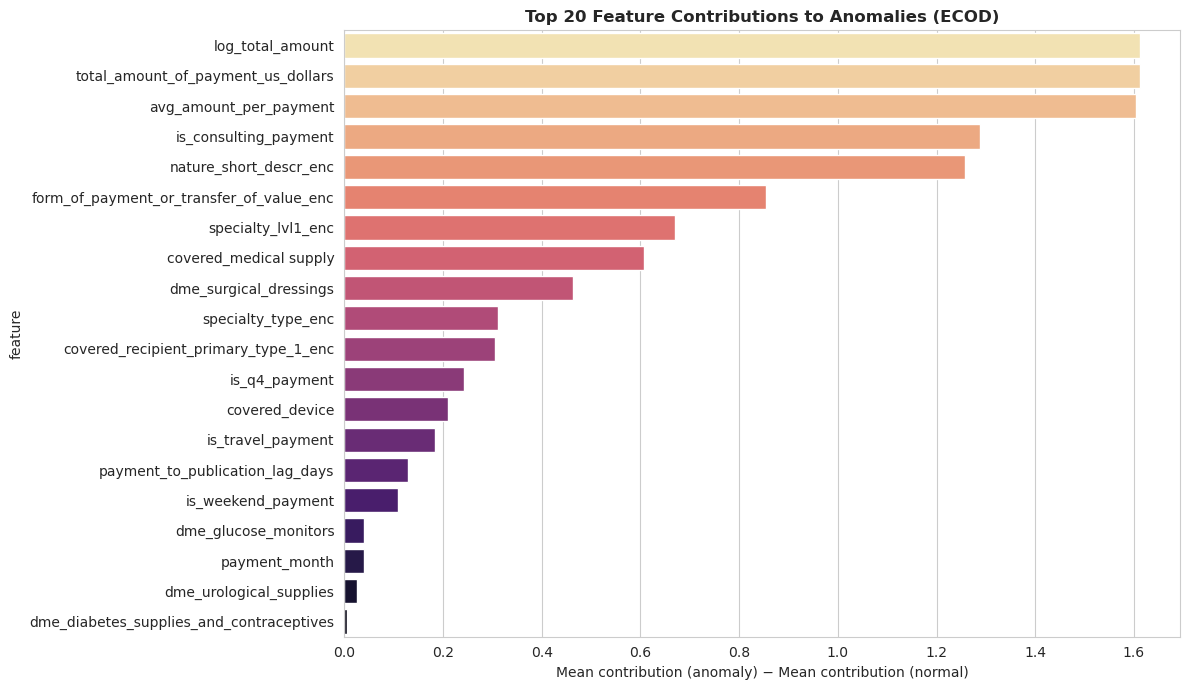

In [15]:
# Bar chart of top feature importances
top20 = feature_importance.head(20).reset_index()
top20.columns = ['feature', 'importance']

fig, ax = plt.subplots(figsize=(12, 7))
sns.barplot(data=top20, x='importance', y='feature', palette='magma_r', ax=ax)
ax.set_title('Top 20 Feature Contributions to Anomalies (ECOD)', fontweight='bold')
ax.set_xlabel('Mean contribution (anomaly) − Mean contribution (normal)')
plt.tight_layout()
plt.show()

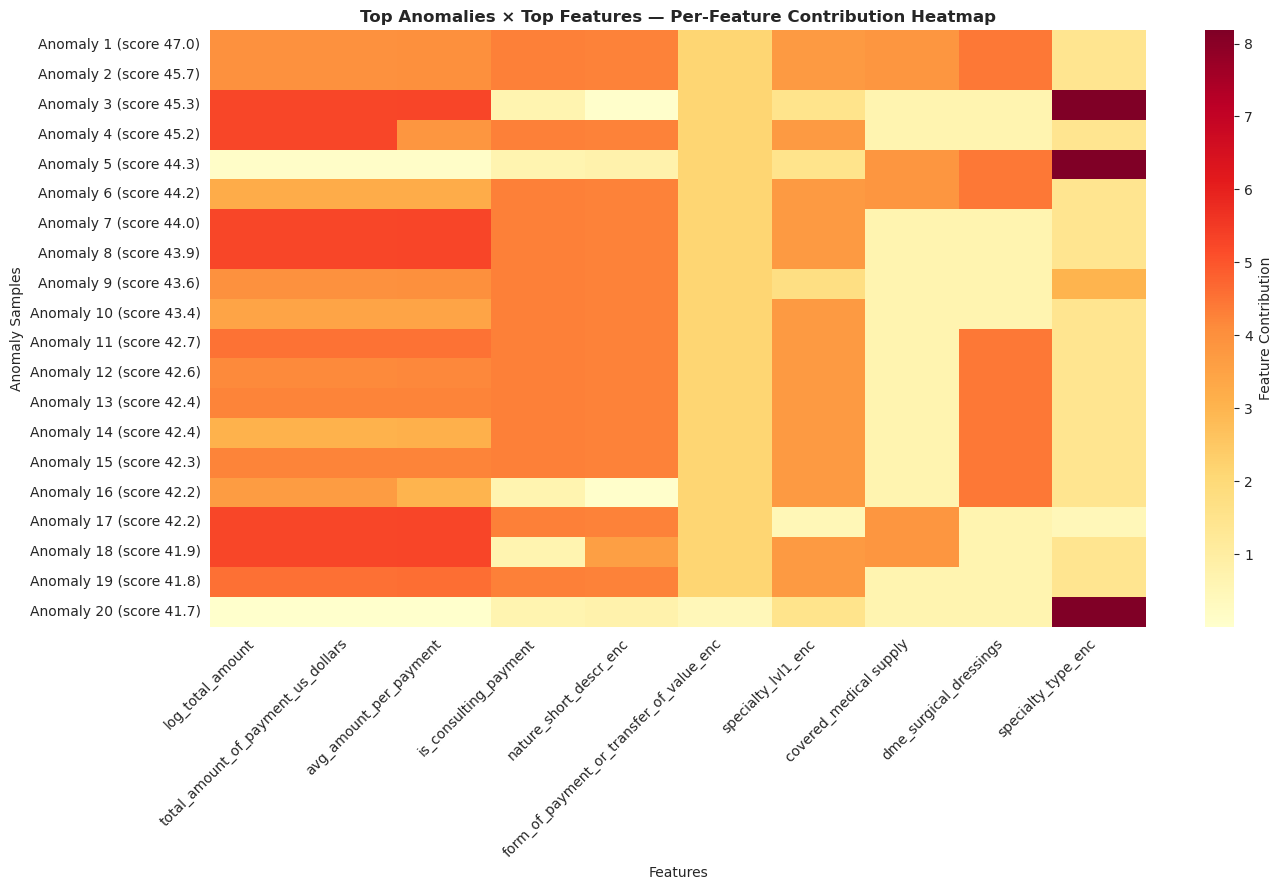

In [16]:
# Heatmap: top anomalies × top features
n_top = 20
top_anomaly_idx  = np.argsort(test_scores)[-n_top:][::-1]
top_feature_names = feature_importance.head(10).index.tolist()
heatmap_data      = test_contributions.iloc[top_anomaly_idx][top_feature_names]

fig, ax = plt.subplots(figsize=(14, 9))
sns.heatmap(
    heatmap_data.values,
    xticklabels=top_feature_names,
    yticklabels=[f'Anomaly {i+1} (score {test_scores[idx]:.1f})'
                 for i, idx in enumerate(top_anomaly_idx)],
    cmap='YlOrRd',
    cbar_kws={'label': 'Feature Contribution'},
    ax=ax
)
ax.set_title('Top Anomalies × Top Features — Per-Feature Contribution Heatmap', fontweight='bold')
ax.set_xlabel('Features')
ax.set_ylabel('Anomaly Samples')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Individual Anomaly Explanation Examples


In [17]:
N_EXPLAIN = 3   # Number of top anomalies to explain in detail

top_indices = np.argsort(test_scores)[-N_EXPLAIN:][::-1]
X_test_df   = pd.DataFrame(X_test, columns=feature_cols)

for rank, idx in enumerate(top_indices, 1):
    score     = test_scores[idx]
    pct_rank  = stats.percentileofscore(test_scores, score)
    contrib_row = test_contributions.iloc[idx]
    top_contribs = contrib_row.sort_values(ascending=False).head(10)

    print('=' * 70)
    print(f'ANOMALY #{rank} — Test index {idx}')
    print(f'Overall ECOD Score: {score:.4f}  |  Percentile: {pct_rank:.1f}%')
    print('-' * 70)
    print(f'{"Feature":<45} {"Contribution":>12}  {"Raw Value":>12}')
    print('-' * 70)
    for feat, contrib in top_contribs.items():
        raw_val = X_test_df.iloc[idx][feat]
        print(f'{feat:<45} {contrib:>12.4f}  {raw_val:>12.2f}')
    print()


ANOMALY #1 — Test index 241033
Overall ECOD Score: 46.9766  |  Percentile: 100.0%
----------------------------------------------------------------------
Feature                                       Contribution     Raw Value
----------------------------------------------------------------------
dme_surgical_dressings                              4.4260          1.00
is_consulting_payment                               4.2962          1.00
nature_short_descr_enc                              4.2825          2.00
avg_amount_per_payment                              4.0020       3000.00
log_total_amount                                    3.9894          8.01
total_amount_of_payment_us_dollars                  3.9894       3000.00
covered_medical supply                              3.8621          1.00
specialty_lvl1_enc                                  3.7286          7.00
is_weekend_payment                                  3.3470          1.00
form_of_payment_or_transfer_of_value_enc      

## Confusion Matrix (Top 5% Anomalous as Predicted Fraud)


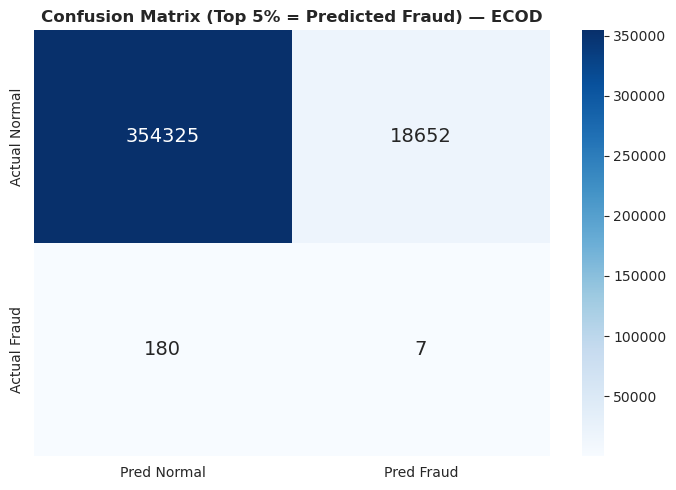

              precision    recall  f1-score   support

      Normal       1.00      0.95      0.97    372977
       Fraud       0.00      0.04      0.00       187

    accuracy                           0.95    373164
   macro avg       0.50      0.49      0.49    373164
weighted avg       1.00      0.95      0.97    373164

Fraud capture rate in top 5%: 7/187 = 3.7%


In [18]:
top5_cutoff  = np.percentile(test_scores, 95)
y_pred_top5  = (test_scores >= top5_cutoff).astype(int)
cm           = confusion_matrix(y_test, y_pred_top5)
tn, fp, fn, tp = cm.ravel()

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Pred Normal', 'Pred Fraud'],
            yticklabels=['Actual Normal', 'Actual Fraud'],
            annot_kws={'size': 14}, ax=ax)
ax.set_title('Confusion Matrix (Top 5% = Predicted Fraud) — ECOD', fontweight='bold')
plt.tight_layout()
plt.show()

print(classification_report(y_test, y_pred_top5, target_names=['Normal', 'Fraud']))
print(f'Fraud capture rate in top 5%: {tp}/{tp+fn} = {tp/(tp+fn)*100:.1f}%')

## Save Model and Artifacts for Ensemble Integration


In [19]:
joblib.dump(ecod,   OUT_MODEL)
joblib.dump(scaler, OUT_SCALER)

reference_data = {
    'model_type':       'ecod',
    'contamination':    CONTAMINATION,
    'auprc':            float(auprc_val),
    'roc_auc':          float(roc_auc),
    'feature_cols':     feature_cols,
    'bin_percentiles':  BIN_PERCENTILES,
    'bin_labels':       BIN_LABELS,
    'bin_cutoffs':      cutoffs.tolist(),
    'ecod_threshold':   float(ecod.threshold_),
    'all_score_mean':   float(all_scores.mean()),
    'all_score_std':    float(all_scores.std()),
    'feature_importance': feature_importance.head(20).to_dict(),
}
joblib.dump(reference_data, OUT_REFS)

out_df = df[ID_COLS + [TARGET_COL]].copy()
out_df['ecod_anomaly_score'] = all_scores
out_df['ecod_anomaly_bin']   = all_bins
out_df = out_df.sort_values('ecod_anomaly_score', ascending=False)
out_df.to_csv(OUT_CSV, index=False)

print(f'Model:  {OUT_MODEL}')
print(f'Scaler: {OUT_SCALER}')
print(f'Refs: {OUT_REFS}')
print(f'CSV: {OUT_CSV}')
print(f'\nBin cutoffs persisted: {dict(zip(BIN_PERCENTILES, cutoffs.round(4)))}')
print(f'\nTop 10 most anomalous records:')
out_df.head(10)

Model:  ecod_model.pkl
Scaler: ecod_scaler.pkl
Refs: ecod_reference_scores.pkl
CSV: ecod_predictions.csv

Bin cutoffs persisted: {50: 16.8385, 90: 24.7138, 95: 27.3587}

Top 10 most anomalous records:


,covered_recipient_npi,record_id,program_year,target,ecod_anomaly_score,ecod_anomaly_bin
670310,1871606624,1048178369,2023.0,0,48.886419,Critical
271351,1346253580,1048132181,2023.0,0,47.031434,Critical
818199,1962648410,835488313,2021.0,0,46.975770,Critical
831270,1255337580,1048124497,2023.0,0,46.299934,Critical
643090,1043627292,1060446733,2023.0,0,45.764973,Critical
443742,1629076674,835487723,2021.0,0,45.738045,Critical
60244,1366458275,1048133789,2023.0,0,45.344143,Critical
915851,1508327826,1022220179,2023.0,0,45.203943,Critical
876537,1871910620,1060558259,2023.0,0,45.178309,Critical
714405,1114074093,1048112063,2023.0,0,45.075345,Critical


In [20]:
#########################################################
# Aggregate ECOD Scores to Provider-Year
#####################################################
PROVIDER_COL = ID_COLS[0]          # 'covered_recipient_npi'
YEAR_COL     = ID_COLS[2]          # 'program_year'
CRITICAL_BIN = BIN_LABELS[-1]      # 'Critical'
HIGH_BIN     = BIN_LABELS[-2]      # 'High'
P90_CUTOFF   = cutoffs[1]          # 90th percentile
P95_CUTOFF   = cutoffs[2]          # 95th percentile

# Re-attach identifiers and scores to a single working frame
rollup_df = df[ID_COLS + [TARGET_COL]].copy()
rollup_df['ecod_score'] = all_scores
rollup_df['ecod_bin']   = all_bins

# Aggregate to provider-year
provider_year = rollup_df.groupby([PROVIDER_COL, YEAR_COL]).agg(
    ecod_tx_count        = ('ecod_score', 'count'),
    ecod_score_mean      = ('ecod_score', 'mean'),
    ecod_score_max       = ('ecod_score', 'max'),
    ecod_score_std       = ('ecod_score', 'std'),
    ecod_n_above_p90     = ('ecod_score', lambda s: (s >= P90_CUTOFF).sum()),
    ecod_n_above_p95     = ('ecod_score', lambda s: (s >= P95_CUTOFF).sum()),
    ecod_pct_flagged     = ('ecod_score', lambda s: (s >= P95_CUTOFF).mean()),
    ecod_n_critical      = ('ecod_bin',   lambda s: (s == CRITICAL_BIN).sum()),
    ecod_pct_critical    = ('ecod_bin',   lambda s: (s == CRITICAL_BIN).mean()),
    ecod_has_any_critical= ('ecod_bin',   lambda s: int((s == CRITICAL_BIN).any())),
    target               = (TARGET_COL,   'max'),   # provider-level label
).reset_index()

OUT_ROLLUP = 'ecod_provider_year_rollup.csv'
provider_year.to_csv(OUT_ROLLUP, index=False)

print(f'Provider-year rollup shape: {provider_year.shape}')
print(f'Providers with any Critical transaction: {provider_year["ecod_has_any_critical"].sum()}')
print(f'Saved to {OUT_ROLLUP}')
provider_year.head()

Provider-year rollup shape: (158751, 13)
Providers with any Critical transaction: 13685
Saved to ecod_provider_year_rollup.csv


,covered_recipient_npi,program_year,ecod_tx_count,ecod_score_mean,ecod_score_max,ecod_score_std,ecod_n_above_p90,ecod_n_above_p95,ecod_pct_flagged,ecod_n_critical,ecod_pct_critical,ecod_has_any_critical,target
0,1003000597,2021.0,4,19.690183,20.437322,1.189408,0,0,0.0,0,0.0,0,0
1,1003000597,2022.0,17,18.537599,27.004201,3.849924,2,0,0.0,0,0.0,0,0
2,1003000597,2023.0,30,16.936507,23.557028,3.245476,0,0,0.0,0,0.0,0,0
3,1003000902,2021.0,1,22.087596,22.087596,NaN,0,0,0.0,0,0.0,0,0
4,1003000902,2022.0,1,19.929689,19.929689,NaN,0,0,0.0,0,0.0,0,0


In [21]:
from sklearn.metrics import average_precision_score
from scipy.stats import mannwhitneyu
import numpy as np

# Keep only labeled rows
labeled = out_df.dropna(subset=[TARGET_COL]).copy()

# Pull the held-out test-set scores and labels for evaluation
test_eval = pd.DataFrame({
    "target": y_test,
    "ecod_score_mean": test_scores
}).dropna(subset=["target"])

# Compute the baseline prevalence on the held-out test set
baseline = test_eval["target"].mean()

# Compute AUPRC using the correct score direction; higher score = more anomalous
auprc = average_precision_score(
    test_eval["target"],
    test_eval["ecod_score_mean"]
)

# Compute adjusted AUPRC relative to the baseline prevalence
adjusted_auprc = (auprc - baseline) / (1 - baseline)

# Split test scores by class for an independent-samples rank test
fraud_scores = test_eval.loc[
    test_eval["target"] == 1,
    "ecod_score_mean"
].to_numpy()

normal_scores = test_eval.loc[
    test_eval["target"] == 0,
    "ecod_score_mean"
].to_numpy()

# Run a one-sided Mann-Whitney U test; fraud should have higher anomaly scores
u_stat, p = mannwhitneyu(
    fraud_scores,
    normal_scores,
    alternative="greater",
    method="asymptotic"
)

# Guard against underflow when formatting extremely small p-values
p_display = f"{p:.3e}" if p > 0 else "< 1e-308"

# Print a clean summary
print(
    "DECISION GATE 2 - ECOD:\n"
    f"Model AUPRC: {auprc:.4f}\n"
    f"Dataset Baseline AUPRC: {baseline:.4f}\n"
    f"Adjusted AUPRC: {adjusted_auprc:.4f}\n"
    f"Mann-Whitney U statistic: {u_stat:.1f}\n"
    f"Mann-Whitney p: {p_display}"
)

DECISION GATE 2 - ECOD:
Model AUPRC: 0.0007
Dataset Baseline AUPRC: 0.0005
Adjusted AUPRC: 0.0002
Mann-Whitney U statistic: 43995093.0
Mann-Whitney p: 2.937e-10
